In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/rahulvyasm/medical-insurance-cost-prediction/medical_insurance.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
# First 5 Rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 2772
Columns : 7


In [8]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [10]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [11]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 1435


In [13]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (1337, 7)


In [14]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [15]:
for col in df.columns:
    print("="*40)
    print(col)
    print(df[col].unique())

age
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex
['female' 'male']
bmi
[27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.1
 23.75  28.975 31.35  33.915 28.785 28.3   37.4   17.765 34

In [16]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [17]:
print("Minimum Charges :", df["charges"].min())

print("Maximum Charges :", df["charges"].max())

print("Average Charges :", df["charges"].mean())

Minimum Charges : 1121.8739
Maximum Charges : 63770.42801
Average Charges : 13279.121486655948


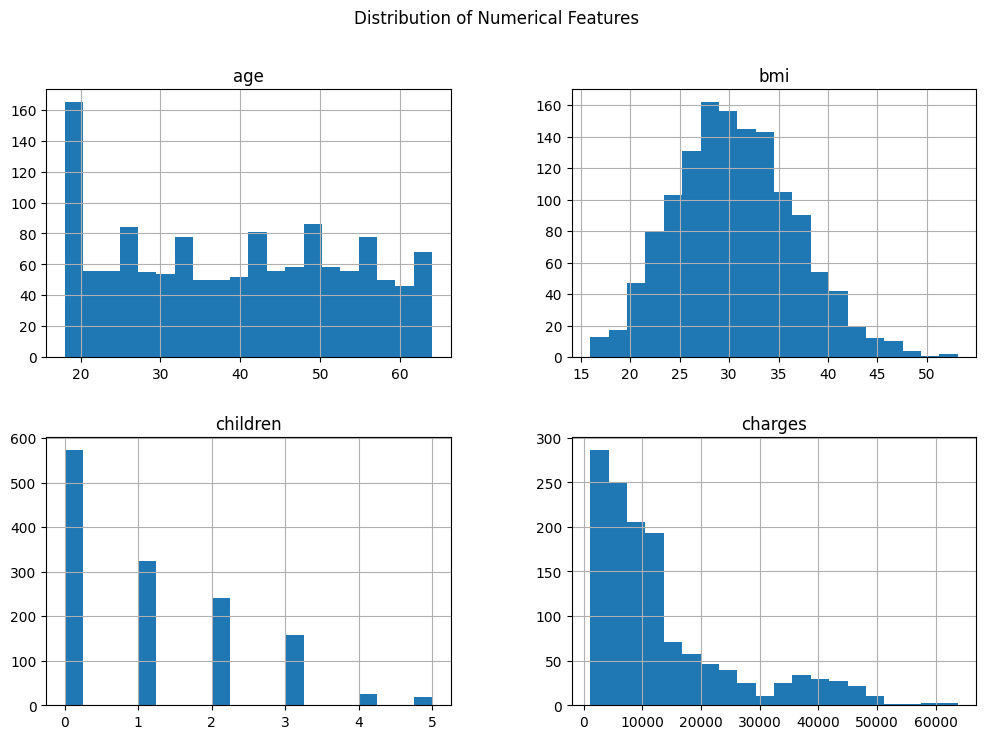

In [18]:
numerical_columns = ['age', 'bmi', 'children', 'charges']

df[numerical_columns].hist(figsize=(12,8), bins=20)

plt.suptitle("Distribution of Numerical Features")

plt.show()

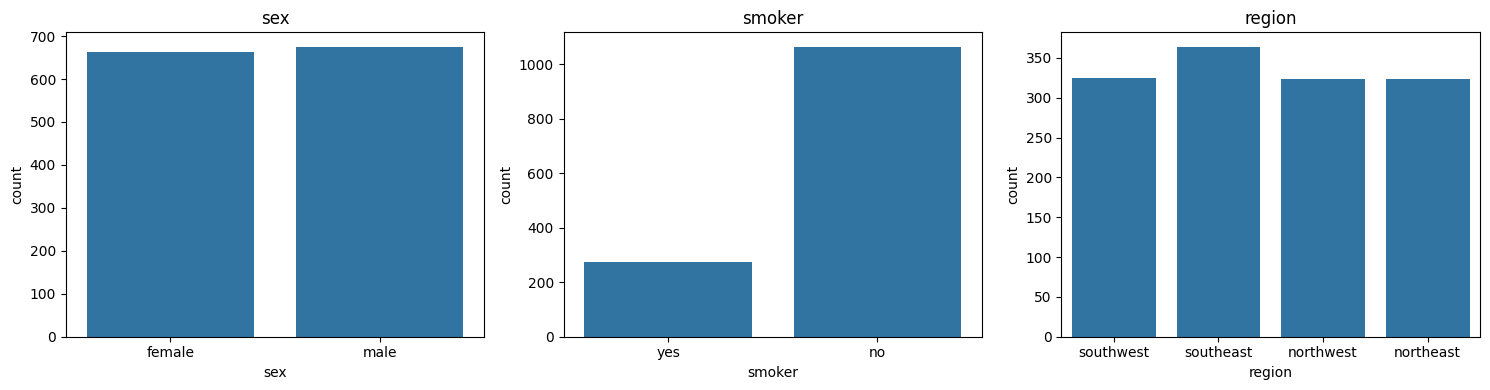

In [19]:
categorical_columns = ['sex', 'smoker', 'region']

plt.figure(figsize=(15,4))

for i, col in enumerate(categorical_columns):
    plt.subplot(1,3,i+1)
    sns.countplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

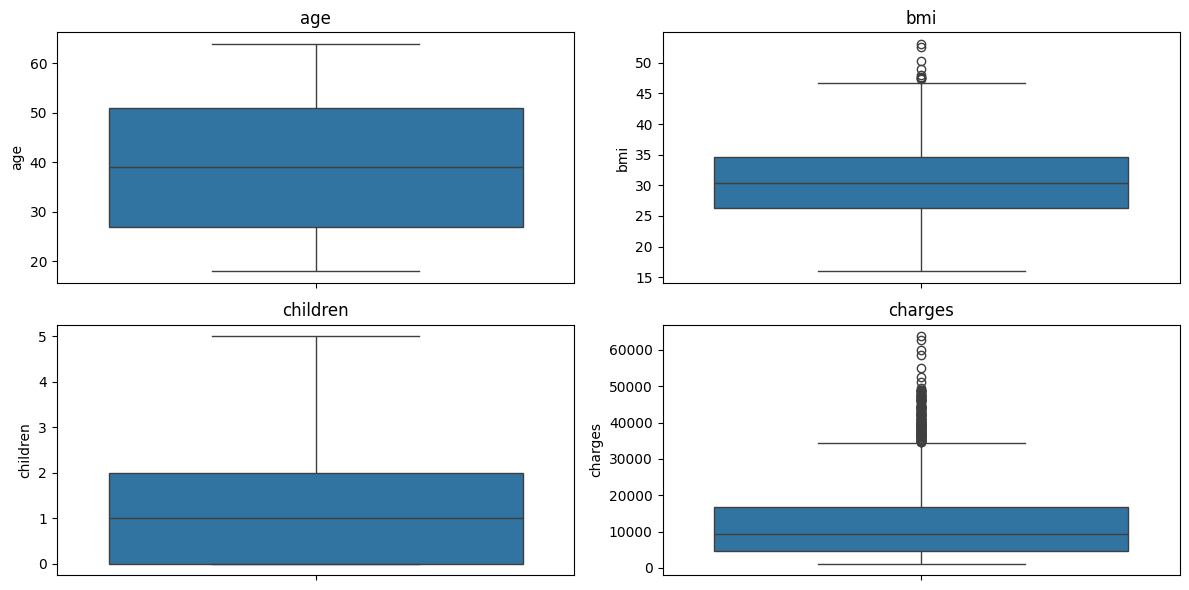

In [20]:
plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

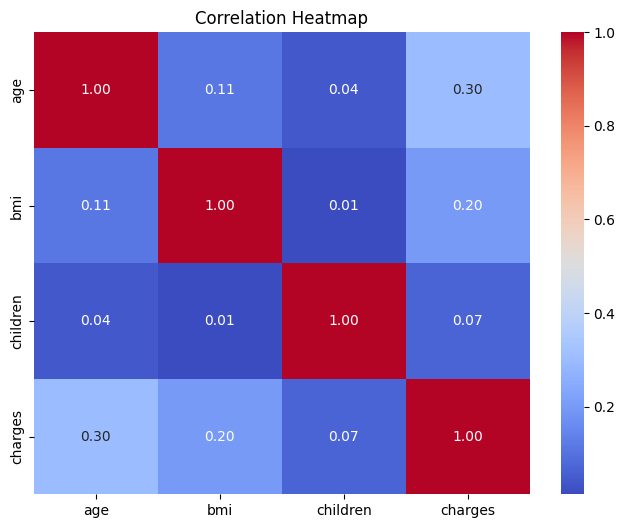

In [21]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

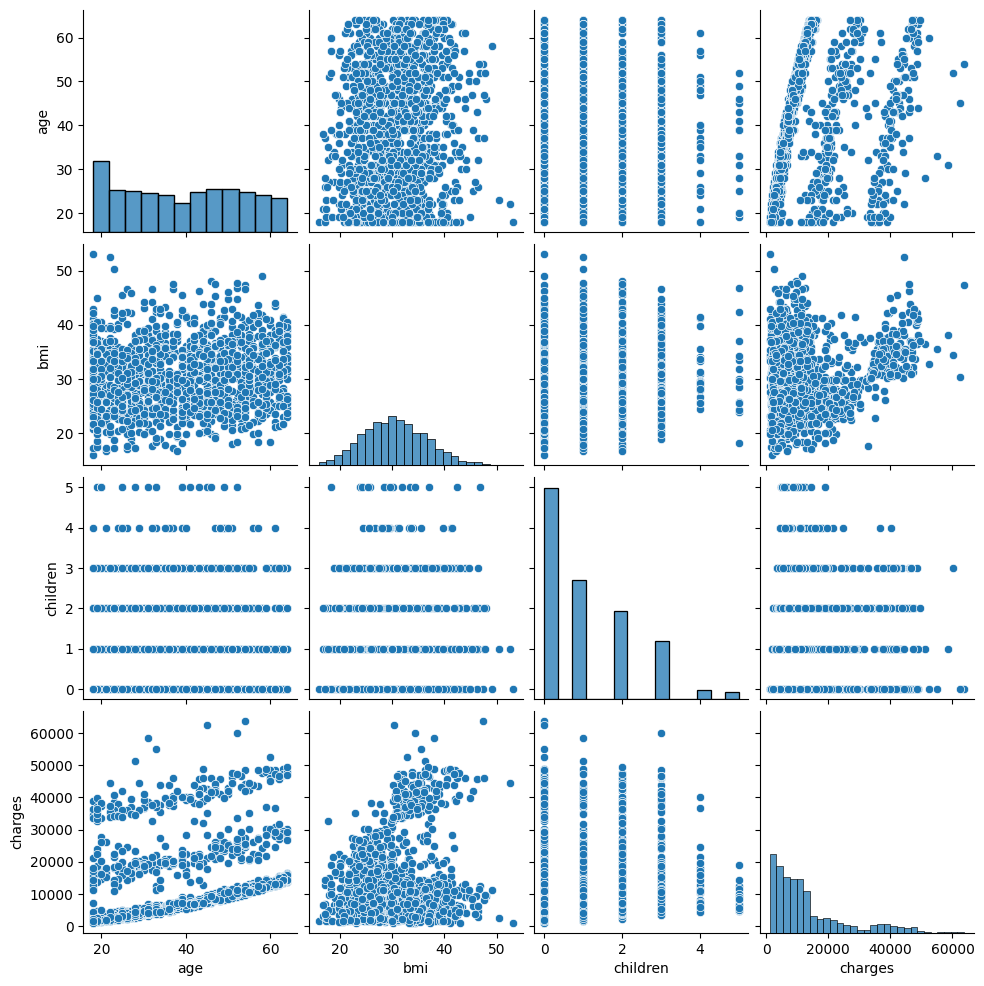

In [22]:
sns.pairplot(df)

plt.show()

In [23]:
X = df.drop("charges", axis=1)

y = df["charges"]

print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (1337, 6)
Target Shape : (1337,)


In [24]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded Features Shape :", X.shape)

X.head()

Encoded Features Shape : (1337, 8)


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [26]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,-1.009771,1.969660,-0.565546,-0.611638,1.764609
1,-1.511647,0.509422,-0.079442,0.990324,-0.507702,-0.565546,1.634955,-0.566698
2,-0.799350,0.383155,1.580143,0.990324,-0.507702,-0.565546,1.634955,-0.566698
3,-0.443201,-1.305052,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698
4,-0.514431,-0.292456,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 1069
Testing Samples : 268


In [30]:
print("X Train Shape :", X_train.shape)

print("X Test Shape :", X_test.shape)

print("Y Train Shape :", y_train.shape)

print("Y Test Shape :", y_test.shape)

X Train Shape : (1069, 8)
X Test Shape : (268, 8)
Y Train Shape : (1069,)
Y Test Shape : (268,)


In [31]:
print("Missing Values in X_train")

print(X_train.isnull().sum().sum())

print()

print("Missing Values in X_test")

print(X_test.isnull().sum().sum())

Missing Values in X_train
0

Missing Values in X_test
0


In [32]:
X.columns

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [33]:
X.head(10)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,-1.009771,1.969660,-0.565546,-0.611638,1.764609
1,-1.511647,0.509422,-0.079442,0.990324,-0.507702,-0.565546,1.634955,-0.566698
2,-0.799350,0.383155,1.580143,0.990324,-0.507702,-0.565546,1.634955,-0.566698
3,-0.443201,-1.305052,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698
4,-0.514431,-0.292456,-0.909234,0.990324,-0.507702,1.768203,-0.611638,-0.566698
5,-0.585661,-0.807363,-0.909234,-1.009771,-0.507702,-0.565546,1.634955,-0.566698
6,0.482785,0.455307,-0.079442,-1.009771,-0.507702,-0.565546,1.634955,-0.566698
7,-0.158282,-0.479397,1.580143,-1.009771,-0.507702,1.768203,-0.611638,-0.566698
8,-0.158282,-0.136672,0.750351,0.990324,-0.507702,-0.565546,-0.611638,-0.566698
9,1.480002,-0.790965,-0.909234,-1.009771,-0.507702,1.768203,-0.611638,-0.566698


In [34]:
# Create Linear Regression Model
model = LinearRegression()

print("Model Created Successfully!")

Model Created Successfully!


In [35]:
# Train Model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [36]:
print("Intercept:")
print(model.intercept_)

Intercept:
13193.879246851913


In [37]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef

,Feature,Coefficient
0,age,3484.650051
1,bmi,1943.500851
2,children,642.341261
3,sex_male,-50.768627
4,smoker_yes,9315.458714
5,region_northwest,-167.867848
6,region_southeast,-373.418692
7,region_southwest,-282.733997


In [38]:
# Predict on Test Data
y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [39]:
result = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

result.head(20)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [42]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 4177.045561036324


In [43]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 35478020.67523558


In [44]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 5956.342894363585


In [41]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8069287081198013


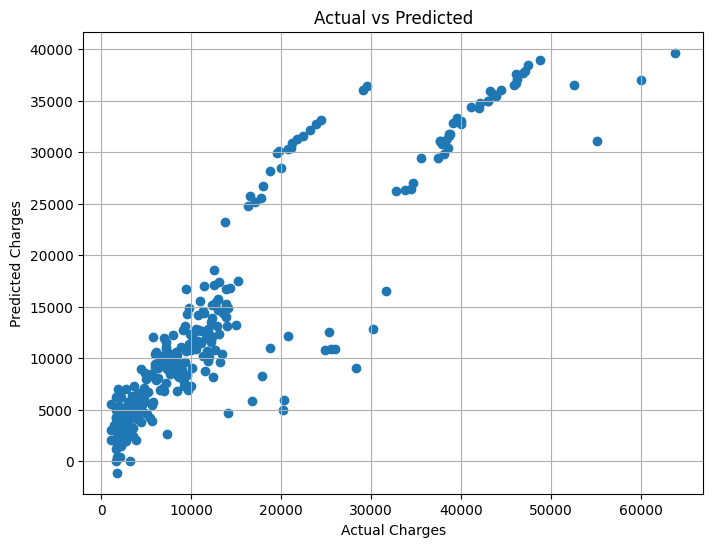

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

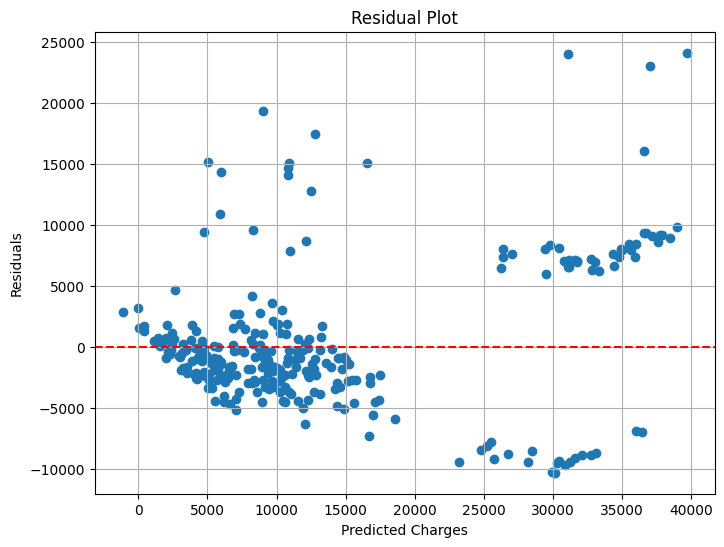

In [46]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

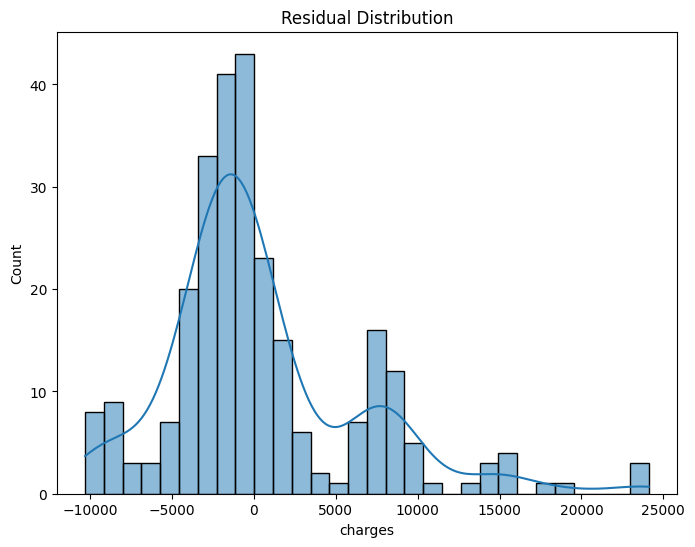

In [49]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")

plt.show()

In [50]:
result.to_csv("Medical_Insurance_Predictions.csv", index=False)

print("CSV File Saved Successfully!")

CSV File Saved Successfully!


In [51]:
print("="*60)
print("      LINEAR REGRESSION PROJECT COMPLETED")
print("="*60)

print("Total Records       :", len(df))
print("Training Samples    :", len(X_train))
print("Testing Samples     :", len(X_test))
print("Number of Features  :", X.shape[1])

print("\nEvaluation Metrics")
print("-"*30)
print("MAE                :", round(mae,2))
print("MSE                :", round(mse,2))
print("RMSE               :", round(rmse,2))
print("R² Score           :", round(r2,4))
print("Model Accuracy     :", round(r2*100,2), "%")

print("="*60)

      LINEAR REGRESSION PROJECT COMPLETED
Total Records       : 1337
Training Samples    : 1069
Testing Samples     : 268
Number of Features  : 8

Evaluation Metrics
------------------------------
MAE                : 4177.05
MSE                : 35478020.68
RMSE               : 5956.34
R² Score           : 0.8069
Model Accuracy     : 80.69 %
